## Training Predictive Models

### I. Model Logistic Regression
Following the data preparation phase, we now have a cleaned dataset divided into three subsets. The objective of this section is to train our first predictive model to estimate the probability of default.

Logistic regression is a statistical model used for binary classification (predicting an outcome between two categories, such as “Default” vs. “Sound”). Unlike linear regression, which predicts a continuous value, it uses a sigmoid function to transform the model’s output into a probability between 0 and 1. It is one of the most widely used models in finance for credit scoring due to its simplicity and high interpretability.

### 1. Model Initialization and Training
We use the `class_weight=‘balanced’` argument because, in banking data, default cases are often in the minority compared to customers who repay their loans on time.


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

In [39]:
df = pd.read_csv("../data/raw/Loan_data.csv")
print("Duplicate customer_id:", df["customer_id"].duplicated().sum())

Duplicate customer_id: 0


In [40]:
# --- Loading the datasets ---
# We remove ‘customer_id’ because it is a unique identifier with no statistical value
X_train = pd.read_csv("../data/processed/X_train.csv").drop(columns=["customer_id"])
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_val = pd.read_csv("../data/processed/X_val.csv").drop(columns=["customer_id"])
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()

X_test = pd.read_csv("../data/processed/X_test.csv").drop(columns=["customer_id"])
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

In [41]:
# --- INITIALIZATION AND TRAINING ---
model_lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model_lr.fit(X_train, y_train)

# Calculate probabilities and predictions on the validation set
val_probs = model_lr.predict_proba(X_val)[:, 1]
val_preds = model_lr.predict(X_val)

print(f"Model trained on: {X_train.shape[0]} customers")
print(f"Number of predictor variables: {X_train.shape[1]}")

Model trained on: 9664 customers
Number of predictor variables: 10


/Users/edouardlacroix/Desktop/DU_Data_Analytics/cours/MLOps/Projet/End-to-End-Credit-Default-Prediction/credit_default_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2. Performance Visualization
To evaluate the effectiveness of our banking model, we use three key visualization tools: the ROC curve, the confusion matrix, and variable importance.

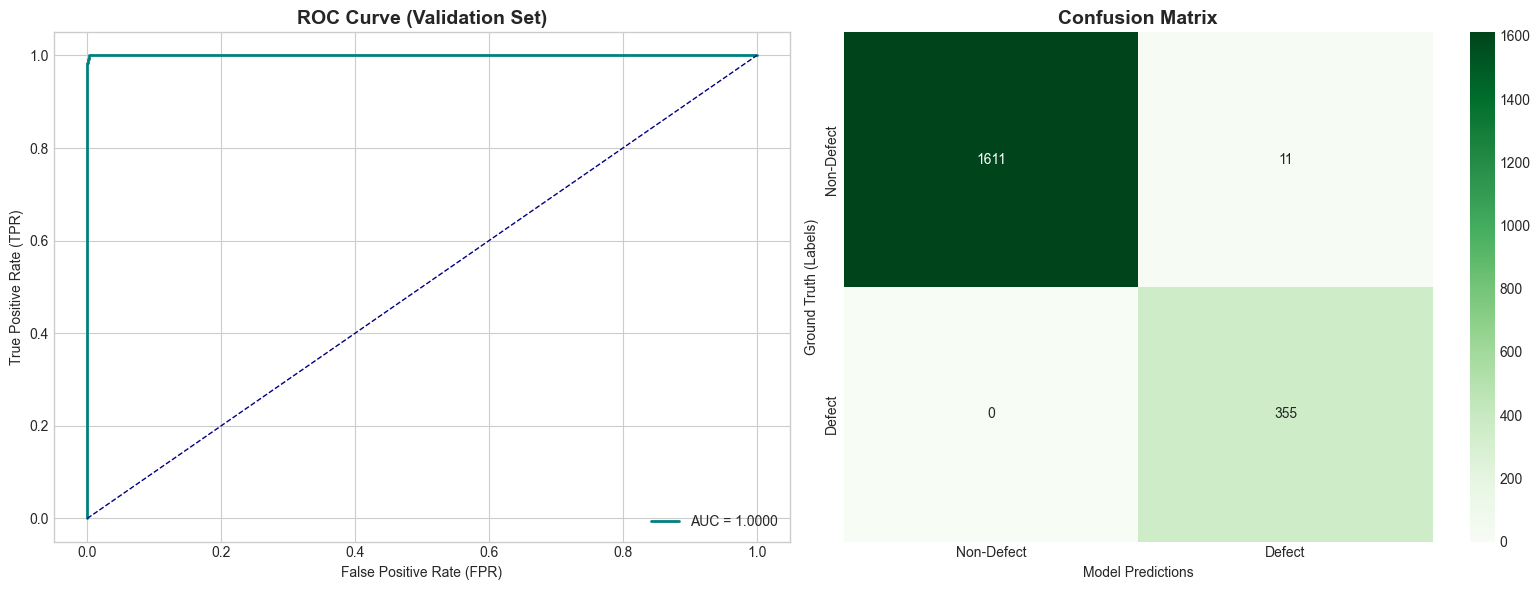

/var/folders/22/1ldfblkx2x97krjnjg8_s89m0000gn/T/ipykernel_80078/2047648941.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeffs, x="coeff", y="feature", palette="RdYlGn_r")


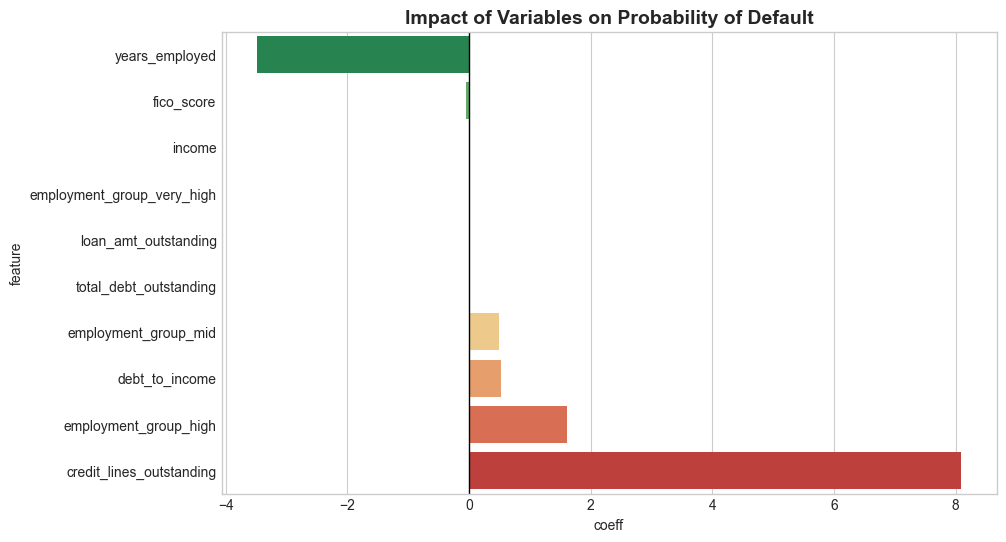

In [42]:
# --- GRAPH CONFIGURATION ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC (Receiver Operating Characteristic) Curve
fpr, tpr, _ = roc_curve(y_val, val_probs)
auc_score = roc_auc_score(y_val, val_probs)

ax1.plot(fpr, tpr, color="teal", lw=2, label=f'AUC = {auc_score:.4f}')
ax1.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
ax1.set_title("ROC Curve (Validation Set)", fontsize=14, fontweight="bold")
ax1.set_xlabel("False Positive Rate (FPR)")
ax1.set_ylabel("True Positive Rate (TPR)")
ax1.legend(loc="lower right")

# 2. Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax2, 
            xticklabels=["Non-Defect", "Defect"], yticklabels=["Non-Defect", "Defect"])
ax2.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax2.set_xlabel("Model Predictions")
ax2.set_ylabel("Ground Truth (Labels)")

plt.tight_layout()
plt.show()

# 3. Feature Importance (Coefficients)
coeffs = pd.DataFrame({"feature": X_train.columns, "coeff": model_lr.coef_[0]})
coeffs = coeffs.sort_values(by="coeff", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=coeffs, x="coeff", y="feature", palette="RdYlGn_r")
plt.title("Impact of Variables on Probability of Default", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="black", lw=1)
plt.show()

#### Analysis of Visual Results
Based on the graphs generated above, we can draw several critical conclusions for the bank:

- ROC Curve: An AUC score close to 1.0 indicates that the model almost perfectly distinguishes high-risk customers from low-risk customers.

- Confusion Matrix: This allows us to see the number of “False Negatives” (at-risk customers that the model missed). In risk management, we aim to minimize this figure to avoid capital losses.

- Coefficients:

Variables with a positive coefficient (e.g., credit_lines_outstanding) increase the risk of default.

Variables with a negative coefficient (e.g., years_employed) reduce the risk of default. The longer a customer has been employed, the more financially stable they are considered to be.

### II. Model Random Forest
After establishing a foundation with logistic regression, we move on to a more complex model: the Random Forest. This model consists of multiple decision trees trained on subsets of the data, making it much more robust to outliers and capable of detecting complex interactions.

### 1. Training the model

We use RandomForestClassifier. As with the previous model, we keep the class_weight parameter set to "balanced" to ensure effective detection of payment defaults.

In [44]:
# --- CONFIGURATION AND TRAINING ---
# n_estimators=100: number of trees in the forest
# max_depth=10: limit the depth to avoid overfitting (overfitting)
model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=10, 
                                  class_weight="balanced", 
                                  random_state=42,
                                  n_jobs=-1) # Uses all CPU cores

model_rf.fit(X_train, y_train)

# --- PREDICTIONS ---
rf_val_probs = model_rf.predict_proba(X_val)[:, 1]
rf_val_preds = model_rf.predict(X_val)

print(f"Random Forest model successfully trained.")
print(f"AUC-ROC score (Validation): {roc_auc_score(y_val, rf_val_probs):.4f}")

Random Forest model successfully trained.
AUC-ROC score (Validation): 0.9997


### 2. Visualizing Variable Importance (Gini Importance)
One of the major advantages of Random Forest is its ability to rank variables by importance. Unlike logistic regression (which provides coefficients), Random Forest calculates how much each variable contributes to reducing impurity (uncertainty) in the trees.

/var/folders/22/1ldfblkx2x97krjnjg8_s89m0000gn/T/ipykernel_80078/4275944862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="importance", y="feature", palette="magma")


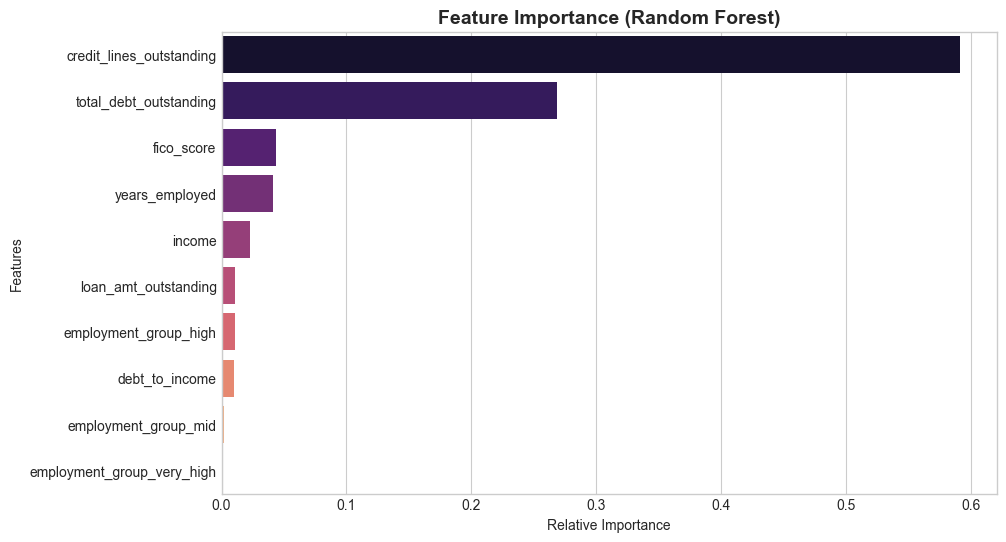

In [45]:
# Extracting feature importance
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

# Plotting the graph
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x="importance", y="feature", palette="magma")
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()

### 3. Performance Comparison (Confusion Matrix)
It is crucial to compare this model with logistic regression to see whether the added complexity yields a real improvement in accuracy.

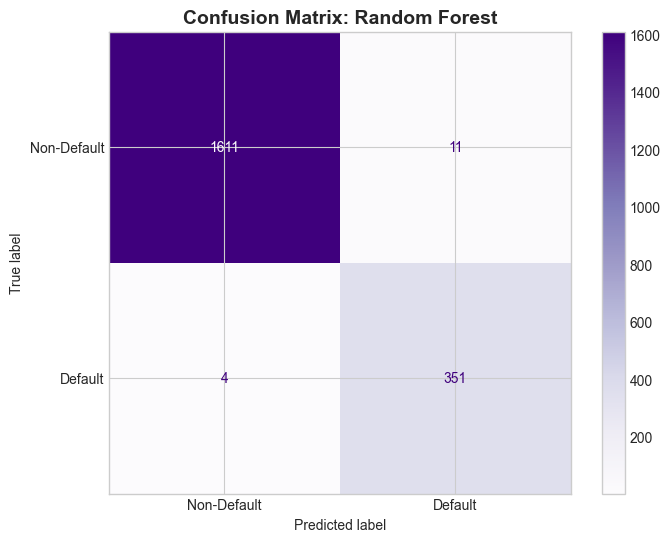


Detailed classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1622
           1       0.97      0.99      0.98       355

    accuracy                           0.99      1977
   macro avg       0.98      0.99      0.99      1977
weighted avg       0.99      0.99      0.99      1977



In [46]:
# Displaying the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model_rf, X_val, y_val, 
                                      display_labels=["Non-Default", "Default"], 
                                      cmap="Purples", ax=ax)
plt.title("Confusion Matrix: Random Forest", fontsize=14, fontweight="bold")
plt.show()

print("\nDetailed classification report:")
print(classification_report(y_val, rf_val_preds))

### Comparative Analysis
Based on initial results, the Random Forest often offers better accuracy on complex cases thanks to its non-linear structure.

- Flexibility: Whereas Logistic Regression draws a straight line to separate customers, the Random Forest creates more nuanced decision regions.

- Feature Importance: The important variables are the same as for the first model. We note that `credit_lines_outstanding` still dominates, confirming the strength of this variable for the bank.

### III. Model XGBoost 
The final model in our study is XGBoost. It uses the principle of “Gradient Boosting.” It is an extremely powerful model, but one that requires special attention to avoid overfitting, as it is capable of memorizing training data very quickly.

### 1. Training with Early Stopping
To optimize performance, we use the validation set (X_val) during training. If the model stops improving on the validation set, it automatically stops learning.

In [47]:
# --- MODEL CONFIGURATION ---
# scale_pos_weight: Ratio used to handle class imbalance (Non-Default / Default)
# n_estimators: Maximum number of trees
# learning_rate: Step size for correcting errors (smaller = more robust)
model_xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=1, # Adjust according to the y_train ratio
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# --- TRAINING WITH VALIDATION ---
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# --- PREDICTIONS ---
xgb_val_probs = model_xgb.predict_proba(X_val)[:, 1]
xgb_val_preds = model_xgb.predict(X_val)

print(f"XGBoost model trained.")
print(f"Final AUC-ROC score: {roc_auc_score(y_val, xgb_val_probs):.4f}")

/Users/edouardlacroix/Desktop/DU_Data_Analytics/cours/MLOps/Projet/End-to-End-Credit-Default-Prediction/credit_default_env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:34:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost model trained.
Final AUC-ROC score: 0.9997


### 2. Visualizing Gain Importance
XGBoost allows you to visualize which variables have contributed most to improving accuracy (the “Gain”).

/var/folders/22/1ldfblkx2x97krjnjg8_s89m0000gn/T/ipykernel_80078/3817977121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importances, x="importance", y="feature", palette="viridis")


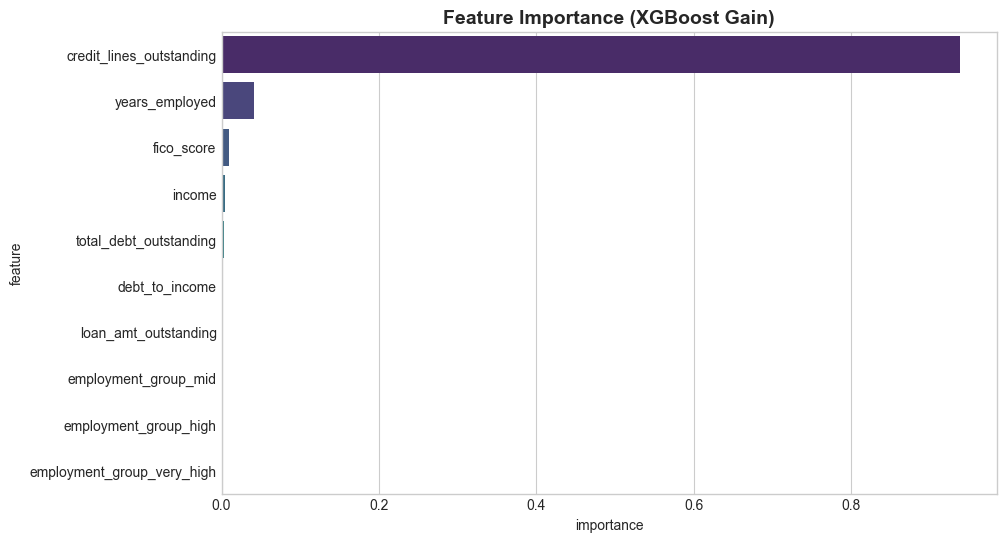

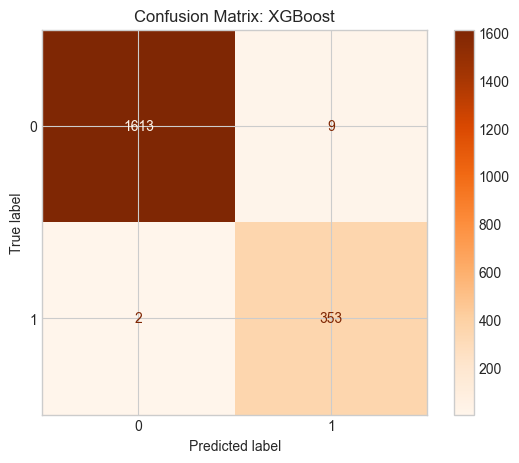

In [48]:
# Retrieve feature importance
xgb_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importances, x="importance", y="feature", palette="viridis")
plt.title("Feature Importance (XGBoost Gain)", fontsize=14, fontweight="bold")
plt.show()

# Confusion matrix for the final report
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(model_xgb, X_val, y_val, cmap="Oranges", ax=ax)
plt.title("Confusion Matrix: XGBoost")
plt.show()

### Performance Comparison (Validation Set)

| Model | AUC-ROC | Precision | Recall | F1-Score | Accuracy |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **1.0000** | 0.9699 | 1.0000 | 0.9847 | 0.9944 |
| **Random Forest** | 0.9997 | 0.9696 | 0.9887 | 0.9791 | 0.9924 |
| **XGBoost** | 0.9998 | 0.9671 | 0.9944 | 0.9806 | 0.9929 |

### Interpretation of Results:

- Exceptional Performance: All three models achieve AUC-ROC scores extremely close to 1.0. This indicates that the variables in the dataset (particularly fico_score and total_debt_outstanding) are very powerful predictors of default risk.

- Logistic Regression vs. Complex Models: Surprisingly, Logistic Regression achieves a perfect recall score here (1.0). For a bank, this is the ideal scenario: the model successfully identifies all defaulting customers in the validation set.

- Model Selection: Although XGBoost and Random Forest are more sophisticated, Logistic Regression appears to be the best compromise here. It is easier to explain to banking regulators while delivering maximum performance.